In [1]:
#Importação de bibliotecas:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt 

#Machine Learning:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error
)
from neuralprophet import NeuralProphet

/Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet/lib/python3.11/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


 * Importação dos dados da Petrobras

In [2]:
#Informações de entrada:
ticker = "PETR4.SA" 
inicio = "2016-01-01"
final = "2026-01-01"

#Dados históricos
#multi_level_index=False nos permite que o data frame possua mais de duas dimensões
ticker = yf.download(ticker, start = inicio, end = final, multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [3]:
#Visualizandos os dados:
ticker

# Nomenclatura:
# Close: preço de fechamento no dia
# High: preço máximo no dia 
# Low: preço mínimo no dia 
# Open: preço de abertura
# Volume: volume negociado

,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,1.830350,1.872978,1.745094,1.750422,45962100
2016-01-05,1.779729,1.864985,1.763743,1.843671,29446700
2016-01-06,1.705129,1.742429,1.705129,1.739765,67507200
2016-01-07,1.667830,1.713122,1.619873,1.649180,57387900
2016-01-08,1.670494,1.718451,1.633195,1.699801,52100300
...,...,...,...,...,...
2025-12-22,30.147873,30.564709,30.147873,30.293280,35896900
2025-12-23,30.309999,30.570000,30.200001,30.549999,35703900
2025-12-26,30.410000,30.430000,30.120001,30.309999,20178600


* Formatação dos dados

In [4]:
# Importante que as datas estejam em objetos datetime:

# Formatação dos dados
ticker = ticker.reset_index()
ticker.columns = ["_".join(col).strip() if isinstance(col, tuple) else col for col in ticker.columns]
ticker = ticker[["Date", "Close"]]
ticker.columns = ["ds", "y"]
ticker["ds"] = pd.to_datetime(ticker["ds"])

ticker


,ds,y
0,2016-01-04,1.830350
1,2016-01-05,1.779729
2,2016-01-06,1.705129
3,2016-01-07,1.667830
4,2016-01-08,1.670494
...,...,...
2486,2025-12-22,30.147873
2487,2025-12-23,30.309999
2488,2025-12-26,30.410000
2489,2025-12-29,30.730000


* Treinamento do modelo

In [5]:
import torch
import pickle

# Fix para PyTorch 2.6+ com NeuralProphet
original_load = torch.load
def patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return original_load(*args, **kwargs)
torch.load = patched_load

# Treinamento:
modelo = NeuralProphet()
modelo.fit(ticker, freq="B")

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - /Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet/lib/python3.11/site-packages/neuralprophet/df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - /Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet/lib/python3.11/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an al

Epoch 90: 100%|██████████| 90/90 [00:00<00:00, 2704.37it/s, loss=0.00685, v_num=1, MAE=1.430, RMSE=2.020, Loss=0.00691, RegLoss=0.000]  


,MAE,RMSE,Loss,RegLoss,epoch
0,50.814144,59.111267,1.214127,0.0,0
1,37.922924,46.227024,0.881047,0.0,1
2,25.253782,33.220039,0.553627,0.0,2
3,14.716240,21.515676,0.287188,0.0,3
4,7.602002,10.586761,0.114955,0.0,4
...,...,...,...,...,...
85,1.423673,2.015684,0.006923,0.0,85
86,1.426549,2.018192,0.006907,0.0,86
87,1.427424,2.023074,0.006912,0.0,87
88,1.421321,2.016520,0.006911,0.0,88


In [6]:
# Criando dataframe com previsões futuras para o próximo 1 ano (365 dias)
dados_futuros = modelo.make_future_dataframe(ticker, periods=365)

# Fazendo previsões para o futuro
previsoes_futuras = modelo.predict(dados_futuros)

# Fazendo previsões passadas (histórico a ser avaliado)
previsoes_passadas = modelo.predict(ticker)

WARNING - (py.warnings._showwarnmsg) - /Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet/lib/python3.11/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 96.347% of the data.
WARNING - (py.warnings._showwarnmsg) - /Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet/lib/python3.11/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - /Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 885.06it/s] 

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (py.warnings._showwarnmsg) - /Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet/lib/python3.11/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 96.347% of the data.
WARNING - (py.warnings._showwarnmsg) - /Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet/lib/python3.11/site-packages/neuralprophet/df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - 


Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 831.71it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [7]:
previsoes_futuras

,ds,y,yhat1,trend,season_yearly,season_weekly
0,2025-12-31,None,34.978813,18.777880,0.278697,15.922235
1,2026-01-01,None,35.059265,18.792187,0.298343,15.968736
2,2026-01-02,None,35.077877,18.806494,0.319147,15.952233
3,2026-01-05,None,35.216240,18.849405,0.388183,15.978648
4,2026-01-06,None,35.172043,18.863712,0.413508,15.894825
...,...,...,...,...,...,...
360,2027-05-19,None,41.382133,25.987726,-0.525910,15.920318
361,2027-05-20,None,41.458321,26.002026,-0.531322,15.987619
362,2027-05-21,None,41.465424,26.016333,-0.535643,15.984736
363,2027-05-24,None,41.550316,26.059244,-0.541397,16.032465


In [8]:
modelo.plot_components(previsoes_futuras)

ERROR - (NP.plotly.plot_components) - plotly-resampler is not installed. Please install it to use the resampler.
WARNING - (py.warnings._showwarnmsg) - /Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet/lib/python3.11/site-packages/neuralprophet/plot_forecast_plotly.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fcst = fcst.fillna(value=np.nan)

WARNING - (py.warnings._showwarnmsg) - /Users/leandrolanzillo/Downloads/GitHub/previsibilidade-de-ações/venv_neuralprophet/lib/python3.11/site-packages/neuralprophet/plot_forecast_plotly.py:410: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the

* Avaliando modelos 

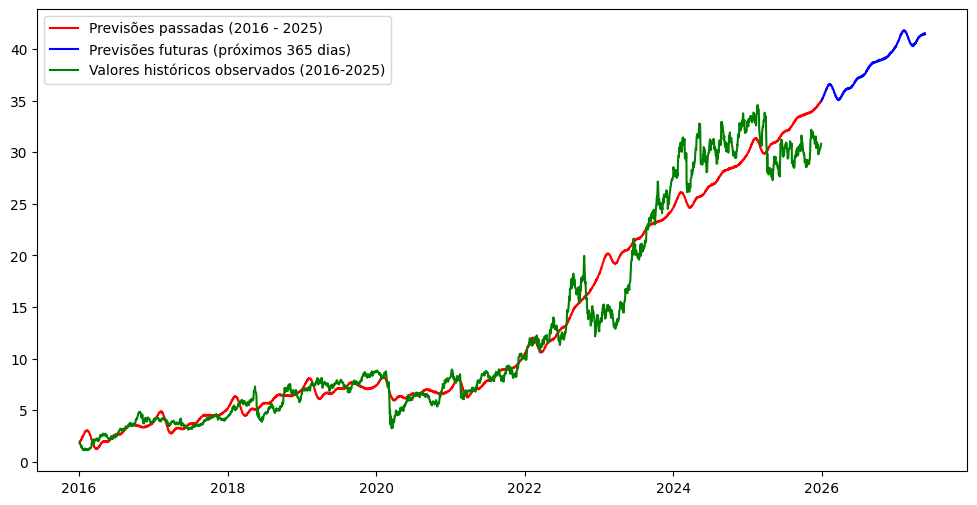

In [15]:
# Criando figura
plt.figure(figsize=(12, 6))

# Gráfico com previsões passadas (vermelho)
plt.plot(
    previsoes_passadas["ds"],
    previsoes_passadas["yhat1"],
    label="Previsões passadas (2016 - 2025)",
    c="r"
)
# Gráfico com previsões futuras (azul)
plt.plot(
    previsoes_futuras["ds"],
    previsoes_futuras["yhat1"],
    label="Previsões futuras (próximos 365 dias)",
    c="b"
)
# Gráfico com dados históricos (verde)
plt.plot(
    ticker["ds"],
    ticker["y"],
    label="Valores históricos observados (2016-2025)",
    c="g"
)
plt.legend()
plt.show()

* Avaliando o modelo

In [ ]:
# R2 mede quanto da variância dos dados é explicada pelo seu modelo:
r2_score(y_true=previsoes_passadas["y"], y_pred=previsoes_passadas["yhat1"])

0.9598674161252304

In [20]:
# Erro médio absoluto(o quanto o modelo erra a respeito do preço da ação em %):
mean_absolute_percentage_error(y_pred=previsoes_passadas["yhat1"], y_true=previsoes_passadas["y"])*100

13.391354871260152